In [1]:
#supress tensorflow log printing
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [2]:
import pandas as pd
from IPython.display import display
import time
import numpy as np
import tools
import misc_tools
from matplotlib import pyplot as plt
import corner
import scipy.stats as stats
import tensorflow as tf
import scipy.stats
%load_ext autoreload
%autoreload 2
models_file = "./models/trained_chiTest4/"

## Data <a class="anchor" id="Data"></a>
Data is loaded from premade txt file made by Dani. Data is processed by the code made by Željko (see 'created_simulated_data.py', read_trilegallsst()).
After that data is split into 4 parts:
   - 'sims': containing all data
   - 'sims1': containing all data with total magnitude < 25
   - 'sims2': containing all data with 25 < total magnitude < 26
   - 'sims3': containing all data with 26 < total magnitude < 27
   - 'simsB': data with 0.2 < g-r < 0.6 and total magnitude < 26 as in Tomography II, where photometric FeH should work the best

Each of the 'sims' is further split into training (70%) validation (15%) and testing (15%) set selected randomly with seed 31.
All models were trained on train-test split on the full data ('sims') and therefore all results are calculated using full dataset.

In [3]:
data = tools.create_simulated_data.txt_file_split_to_npy("../data/simCatalog_three_pix_triout_chiTest4.txt", seed = 31)

'data' is a dictionary containing keys (sims, sims1, sims2, sims3, simsB) and the train and test inputs and output for the model. Inputs are values of the magnitude in the r filter and ug, gr, ri and iz colors, with their respected errors. Outputs are Mr, Ar and Fe/H for each sims cutoff.

In [4]:
sims = "sims"
tables = tools.eval_tools.data_to_pandas(data[sims])
for i, name in enumerate(["TRAIN INPUT", "TRAIN OUTPUT", "VAL INPUT", "VAL OUTPUT", "TEST INPUT", "TEST OUTPUT"]):
    print (name)
    display (tables[i])
    print ()

TRAIN INPUT


,rmag,ug,gr,ri,iz,rmagErr,ugErr,grErr,riErr,izErr
0,20.43,2.497,1.435,1.378,0.724,0.005,0.060299,0.007810,0.007071,0.007071
1,17.93,2.566,1.423,1.030,0.529,0.005,0.012083,0.007071,0.007071,0.007071
2,17.43,1.363,0.453,0.163,0.043,0.005,0.007810,0.007071,0.007071,0.007071
3,18.41,2.552,1.444,1.012,0.539,0.005,0.014866,0.007071,0.007071,0.007071
4,23.14,1.805,1.565,1.941,1.078,0.010,0.405112,0.031623,0.011662,0.008485
...,...,...,...,...,...,...,...,...,...,...
569662,23.82,3.254,1.010,0.362,0.224,0.015,1.703320,0.036249,0.022672,0.030232
569663,23.91,2.415,1.041,0.374,0.193,0.016,0.885773,0.040311,0.024083,0.032450
569664,23.66,2.010,0.660,0.307,0.112,0.013,0.345701,0.025554,0.020616,0.029682
569665,25.44,3.096,1.414,0.515,0.364,0.055,9.541096,0.207425,0.078492,0.095210



TRAIN OUTPUT


,Mr,Ar,FeH
0,11.44,0.096,-0.51
1,9.87,0.102,-0.40
2,4.67,0.114,-0.38
3,9.72,0.138,-0.34
4,13.87,0.102,-0.34
...,...,...,...
569662,6.28,0.311,-0.04
569663,6.14,0.338,-0.04
569664,4.93,0.426,-0.04
569665,6.87,0.400,-0.00



VAL INPUT


...

,Mr,Ar,FeH
0,13.04,0.120,-0.49
1,10.73,0.117,-0.42
2,13.92,0.102,-0.34
3,12.28,0.122,-0.19
4,6.47,0.106,-0.10
...,...,...,...
122122,3.91,0.858,-0.09
122123,8.10,0.064,-0.07
122124,4.32,0.428,-0.07
122125,4.24,0.121,-0.04



TEST INPUT


,rmag,ug,gr,ri,iz,rmagErr,ugErr,grErr,riErr,izErr
0,16.10,2.591,1.309,0.559,0.278,0.005,0.007810,0.007071,0.007071,0.007071
1,19.80,2.577,1.433,1.146,0.594,0.005,0.038471,0.007810,0.007071,0.007071
2,18.75,2.431,1.493,1.609,0.861,0.005,0.017720,0.007071,0.007071,0.007071
3,20.98,2.633,1.461,1.338,0.718,0.005,0.112219,0.008602,0.007071,0.007071
4,21.72,2.083,1.615,1.931,1.069,0.006,0.152398,0.012530,0.007810,0.007071
...,...,...,...,...,...,...,...,...,...,...
122651,20.93,2.816,1.256,0.515,0.244,0.005,0.105233,0.008602,0.007071,0.007810
122652,25.31,3.694,1.388,1.540,0.872,0.049,9.958503,0.179805,0.053712,0.029069
122653,23.86,3.298,1.174,0.422,0.276,0.015,2.155371,0.042720,0.022672,0.028601
122654,24.79,3.564,1.087,0.553,0.242,0.032,5.967577,0.088955,0.044553,0.056303



TEST OUTPUT


,Mr,Ar,FeH
0,7.94,0.112,-0.47
1,10.06,0.135,-0.17
2,12.59,0.069,-0.61
3,11.31,0.122,-0.59
4,13.92,0.106,-0.40
...,...,...,...
122651,7.43,0.054,-0.11
122652,12.10,0.048,-0.09
122653,6.62,0.316,-0.04
122654,6.51,0.399,-0.04


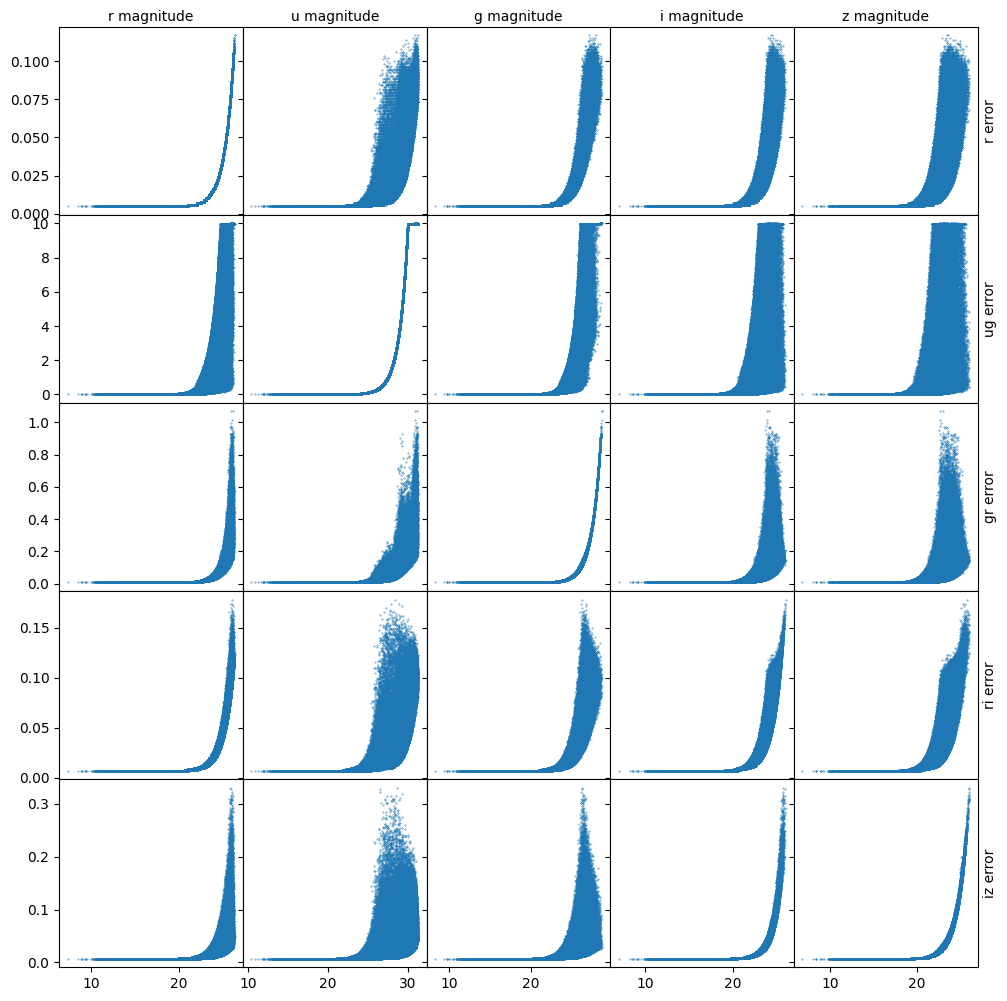

In [5]:
a = misc_tools.plot_magnitudes_error(data[sims])

In [6]:
x_train, y_train, x_val, y_val, x_test, y_test = data[sims]

Now let's plot ugErr vs. ug, color coded by mean true FeH, and by its sigma.

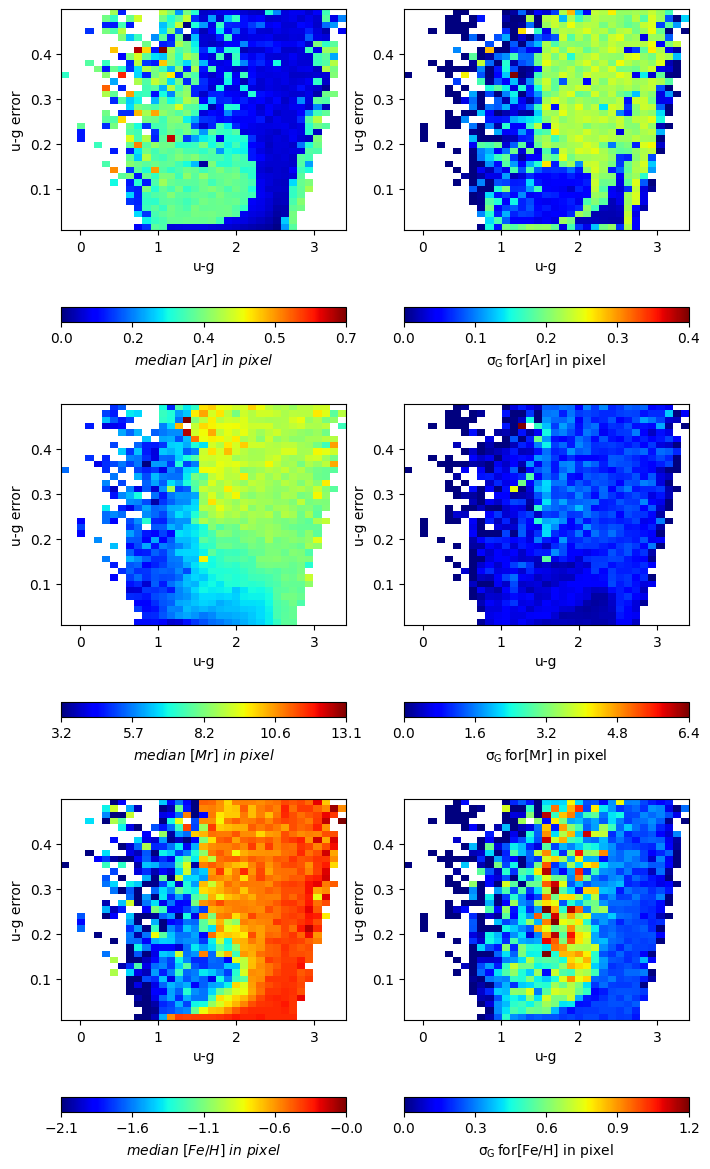

In [7]:
r_magSample, ugSample, grSample, riSample, izSample = (x_test[0][:,i] for i in range (x_test[0].shape[1]))
r_magErrSample, ugErrSample, grErrSample, riErrSample, izErrSample = (x_test[1][:,i] for i in range (x_test[1].shape[1]))
Mrsample, Arsample, FeHsample = (y_test[i][:,0] for i in range (len(y_test)))
fig, ax = plt.subplots(3, 2, figsize=(7, 12))
fig.tight_layout()
ax [0,0] =  tools.eval_tools.plot_pike(Arsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                                       ax[0, 0], statistics="median",value_name="Ar")
ax [0,1] = tools.eval_tools.plot_pike(Arsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                                       ax[0, 1], statistics=tools.eval_tools.sigGzi ,value_name="Ar")

ax [1,0] =  tools.eval_tools.plot_pike(Mrsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                                       ax[1, 0], statistics="median",value_name="Mr")
ax [1,1] = tools.eval_tools.plot_pike(Mrsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                                       ax[1, 1], statistics=tools.eval_tools.sigGzi ,value_name="Mr")

ax [2,0] =  tools.eval_tools.plot_pike(FeHsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                                       ax[2, 0], statistics="median",value_name="Fe/H")
ax [2,1] = tools.eval_tools.plot_pike(FeHsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                                       ax[2, 1], statistics=tools.eval_tools.sigGzi ,value_name="Fe/H")

(2.0, 13.0)

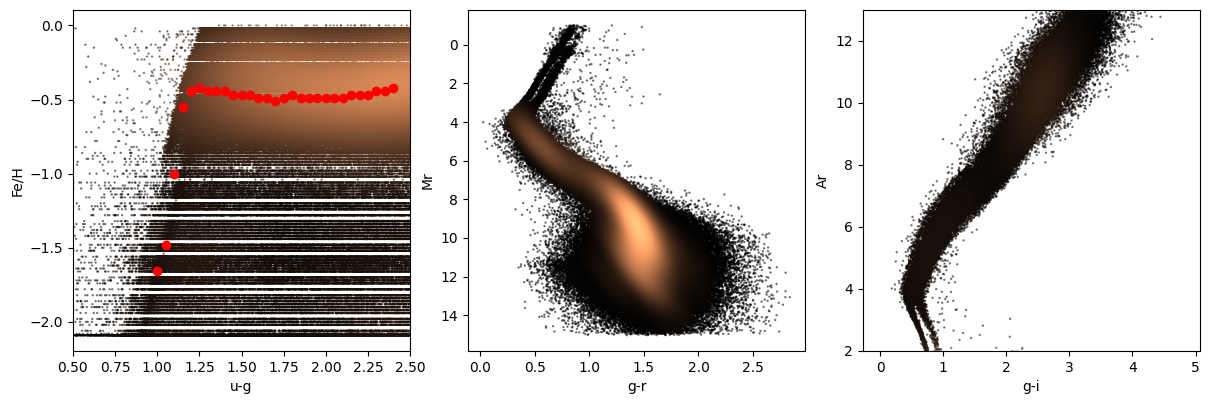

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
fig.tight_layout()

ug = np.concatenate([x_train[0][:,1], x_val[0][:,1], x_test[0][:,1]])
feh = np.concatenate([y_train[2][:,0], y_val[2][:,0], y_test[2][:,0]])
ug, feh, z = tools.eval_tools.density_color_mask(ug, feh, small_size=400)
ax[0].scatter(ug, feh, s=0.5, c=z, alpha=0.5, cmap="copper")
ax[0].set_xlabel("u-g")
ax[0].set_ylabel("Fe/H")
median = stats.binned_statistic(ug, feh, statistic='median', bins=np.arange(1, 2.50, 0.05))
ax[0].scatter(median.bin_edges[:-1], median.statistic, color="red", label="median")
ax[0].set_xlim(0.5, 2.5)

gr = np.concatenate([x_train[0][:,2], x_val[0][:,2], x_test[0][:,2]])
mr = np.concatenate([y_train[0][:,0], y_val[0][:,0], y_test[0][:,0]])
gr, mr, z = tools.eval_tools.density_color_mask(gr, mr, small_size=400)
ax[1].scatter(gr, mr, s=0.5, c=z, alpha=0.5, cmap="copper")
ax[1].set_xlabel("g-r")
ax[1].set_ylabel("Mr")
ax[1].invert_yaxis()

ar = np.concatenate([y_train[1][:,0], y_val[1][:,0], y_test[0][:,0]])
gr = np.concatenate([x_train[0][:,2], x_val[0][:,2], x_test[0][:,2]])
ri = np.concatenate([x_train[0][:,3], x_val[0][:,3], x_test[0][:,3]])
gi = gr + ri
ug = np.concatenate([x_train[0][:,1], x_val[0][:,1], x_test[0][:,1]])
ar, gi, z = tools.eval_tools.density_color_mask(ar, gi, small_size=400)
ax[2].scatter(gi, ar, s=0.5, c=z, alpha=0.5, cmap="copper")
ax[2].set_xlabel("g-i")
ax[2].set_ylabel("Ar")
ax[2].set_ylim(2, 13)